# Stellar objects identification with Machine Learning

### Inteligencia Artificial para los Sistemas de Control Autónomos
### Máster de Ciencia y Tecnología desde el Espacio


## Objectives

- Deal with an open Machine Learning problem.
- Classification of tabular unbalanced data.
- Hyperparameter optimization with grid and random search.
- Handle outliers.

## Introduction

The [Sloan Digital Sky Survey](https://www.sdss.org/) (or SDSS) is, according to [Wikipedia](https://en.wikipedia.org/wiki/Sloan_Digital_Sky_Survey), "a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States". It contains a huge database in which each night hundreds of gigabytes are added.

In this practice we will start from a data set of stellar objects to train a model that identifies the type of object it is from among three categories: Galaxy, star or quasar. The dataset contains 100.000 instances, it is unbalanced and contains a large number of outliers.

The features that the dataset contains are the following ones:

*    *obj_ID* = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
*    *alpha* = Right Ascension angle (at J2000 epoch)
*    *delta* = Declination angle (at J2000 epoch)
*    *u* = Ultraviolet filter in the photometric system
*    *g* = Green filter in the photometric system
*    *r* = Red filter in the photometric system
*    *i* = Near Infrared filter in the photometric system
*    *z* = Infrared filter in the photometric system
*    *run_ID* = Run Number used to identify the specific scan
*    *rereun_ID* = Rerun Number to specify how the image was processed
*    *cam_col* = Camera column to identify the scanline within the run
*    *field_ID* = Field number to identify each field
*    *spec_obj_ID* = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
*    *class* = object class (galaxy, star or quasar object)
*    *redshift* = redshift value based on the increase in wavelength
*    *plate* = plate ID, identifies each plate in SDSS
*    *MJD* = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
*    *fiber_ID* = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("https://github.com/dfbarrero/dataCourse/raw/master/assignments/stellar/stellar.zip")

df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

## Exercise: EDA

In [ ]:
df.shape

(100000, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [ ]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [ ]:
df.isna().sum()

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


In [ ]:
df.value_counts("obj_ID")

,count
obj_ID,
1.237659e+18,17
1.237663e+18,13
1.237666e+18,12
1.237664e+18,11
1.237666e+18,11
...,...
1.237661e+18,1
1.237661e+18,1
1.237661e+18,1


In [ ]:
data = df.drop_duplicates(subset="obj_ID")

In [ ]:
data.value_counts("obj_ID")

,count
obj_ID,
1.237681e+18,1
1.237646e+18,1
1.237646e+18,1
1.237646e+18,1
1.237681e+18,1
...,...
1.237646e+18,1
1.237646e+18,1
1.237646e+18,1


In [ ]:
data = df.drop({'run_ID', 'plate', 'field_ID', 'rerun_ID', 'spec_obj_ID', 'MJD', 'fiber_ID'}, axis=1)
data

,obj_ID,alpha,delta,u,g,r,i,z,cam_col,class,redshift
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,GALAXY,0.634794
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,GALAXY,0.779136
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,GALAXY,0.644195
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,GALAXY,0.932346
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,GALAXY,0.116123
...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,2,GALAXY,0.000000
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,1,GALAXY,0.404895
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,4,GALAXY,0.143366
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,4,GALAXY,0.455040


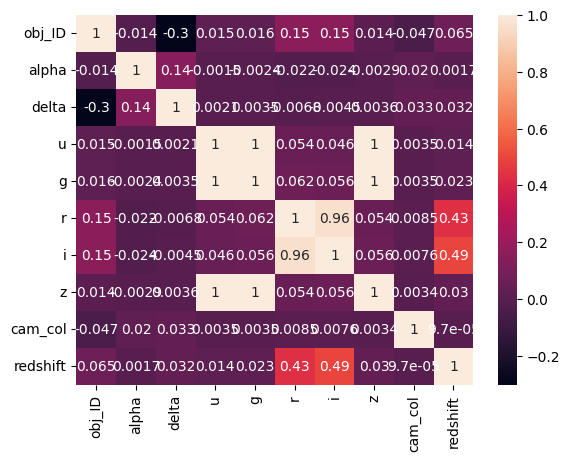

In [ ]:
sns.heatmap(data.select_dtypes(include=['number']).corr(method='pearson'), annot = True);

plt.show()

## Exercise: Data cleaning

Locate the outliers in the dataset and remove them. There are many methods you can use, one quite easy is to visualize a boxplot or histogram of each attribute and drop those values that are too high or low. You also should remove irrelevant or redundant attributes.

<Axes: xlabel='u'>

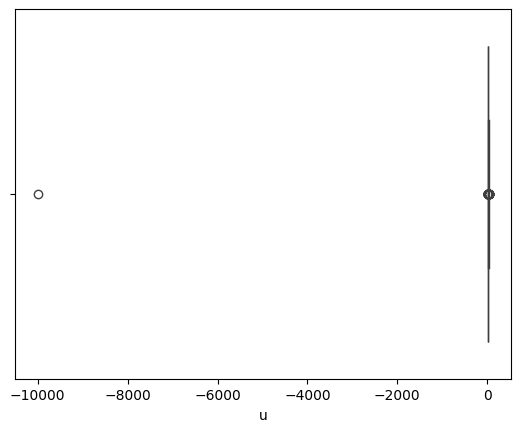

In [ ]:
sns.boxplot(x='u', data=df)

<Axes: xlabel='u'>

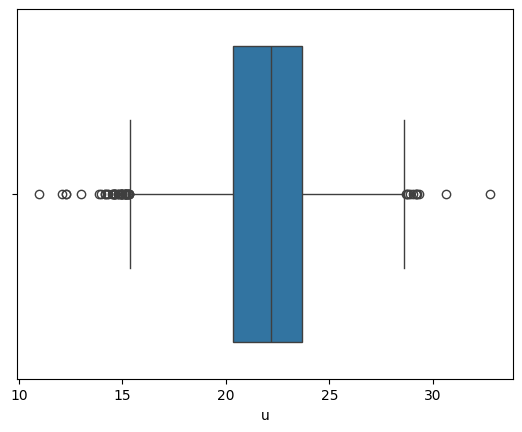

In [ ]:
df = df[df['u']>=0]
sns.boxplot(x='u', data=df)

<Axes: xlabel='redshift'>

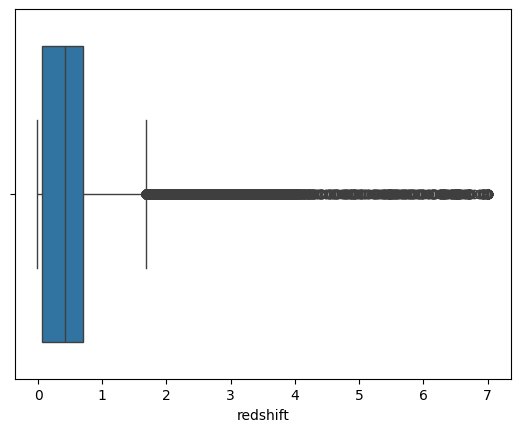

In [ ]:
sns.boxplot(x='redshift', data=df)

In [ ]:
df.value_counts("redshift")

,count
redshift,
0.000000,412
7.011245,6
0.004153,4
0.004153,3
0.629137,3
...,...
0.130105,1
0.130101,1
0.130098,1


In [ ]:
data2 = df[df['redshift']>0.00000]
data2.value_counts("redshift")

,count
redshift,
7.011245,6
0.004153,4
0.629137,3
0.004153,3
0.523821,2
...,...
0.291019,1
0.291015,1
0.291014,1


In [ ]:
print(data['class'].value_counts())

X = data.drop(['class'], axis = 1)
y = data.loc[:,'class'].values

class
GALAXY    47613
STAR      16445
QSO       13994
Name: count, dtype: int64


## Dealing with unbalanced classes
There are several actions that can be taken to address an unbalanced dataset, the best approach will depend on the problem and the data itself.

The classical accuracy used in classification, when there is unbalanced classes, looses reliability. Imagine, for instance, a dataset with 99% of instances of a class A, and only 1% of class B. If we apply a dummy classifier that classifies everything as A, we will obtain an accuracy of 99%, which suggests excellent performance, but clearly this classifier will not be working correctly. For this reason accuracy is rarely used with unbalanced datasets.

One of the most commonly used metrics with unbalanced data is F1, which is defined as the harmonic mean of the precision and recall:

$F1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$.

F1 is defined in a range from zero to one, with one corresponding to a perfect classification. The definition is made for binary classification problems, so it needs to be adapted to multi-label problems like the one we are dealing with. Scikit applies F1 to each class separately, obtaining several F1 values, which it then groups by means of an average. There are several methods to do this grouping. More information in [Scikit-Learn reference documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

Another approach to deal with an unbalanced dataset is to make it a balanced one. The most straightforward way to this is to simply undersample the majority class or oversample the minority class. A variation of the latter is to add noise to the oversampling in a controlled way, so as to bring more variety to the dataset, avoiding overlearning. In the context of Deep Learning this technique is known as "data augmentation".

<img align="center" src="https://github.com/dfbarrero/dataCourse/blob/master/assignments/stellar/smote.webp?raw=1" width="300">

More advanced techniques involve synthetically generating new instances of the minority class. For example, [SMOTE](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/) is a technique of some sophistication and quite popular that creates new instances of the minority class by sampling the straight line joining a minority class instance with some close neighbor.

SMOTE is not supported by Sckit-Learn, we need another library named imblearn.

In [ ]:
!pip install imblearn

In [ ]:
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE


df = pd.read_csv("https://github.com/dfbarrero/dataCourse/raw/master/assignments/stellar/stellar.zip")
print(df['class'].value_counts())

x = df.drop(['class'], axis = 1)
y = df.loc[:,'class'].values

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


In [ ]:
smote= SMOTE()
x_smote, y_smote = smote.fit_resample(x, y)

print(np.unique(y_smote, return_counts=True))

del x_smote, y_smote
del df, x, y

(array(['GALAXY', 'QSO', 'STAR'], dtype=object), array([59445, 59445, 59445]))


## Exercise: Predictive modeling

Train a classifier to identify if a certain object is a galaxy, quasar or star. You can use any technique of your choice to deal with the unbalanced dataset and try, at least, five classifiers. Obtain the best classifier you can without sophisticated hyperparameter optimization.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("https://github.com/dfbarrero/dataCourse/raw/master/assignments/stellar/stellar.zip")

In [ ]:
print(df['class'].value_counts())

X = df.drop(['class'], axis = 1)
y = df.loc[:,'class'].values

class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64


He decidido usar la técnica Balanced Bagging para lidiar con el dataset desbalanceado. Luego, he usado 5 clasificadores distintos. Usando Random Forest sale un accuracy de 0.9730318365255268

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
base_classifier = RandomForestClassifier(random_state=42)

balanced_bagging = BalancedBaggingClassifier(
    estimator=base_classifier,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)

balanced_bagging.fit(X_train, y_train)
y_pred = balanced_bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9730318365255268
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.99      0.97      0.98      9534
         QSO       0.93      0.95      0.94      2758
        STAR       0.98      1.00      0.99      3319

    accuracy                           0.97     15611
   macro avg       0.96      0.97      0.97     15611
weighted avg       0.97      0.97      0.97     15611



Usando SVC, el accuracy es mucho peor: 0.335596694638396

In [ ]:
from sklearn.svm import SVC

modelSVC = SVC(random_state=42)

balanced_bagging = BalancedBaggingClassifier(
    estimator=modelSVC,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)

balanced_bagging.fit(X_train, y_train)
y_pred = balanced_bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.335596694638396
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.68      0.28      0.39      9534
         QSO       0.21      0.27      0.24      2758
        STAR       0.23      0.56      0.32      3319

    accuracy                           0.34     15611
   macro avg       0.37      0.37      0.32     15611
weighted avg       0.50      0.34      0.35     15611



Con KNN mejora un poquito: 0.673947857280123

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

modelKNN = KNeighborsClassifier()

balanced_bagging = BalancedBaggingClassifier(
    estimator=modelKNN,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)

balanced_bagging.fit(X_train, y_train)
y_pred = balanced_bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.673947857280123
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.89      0.76      0.82      9534
         QSO       0.38      0.54      0.45      2758
        STAR       0.50      0.54      0.52      3319

    accuracy                           0.67     15611
   macro avg       0.59      0.61      0.59     15611
weighted avg       0.72      0.67      0.69     15611



Aquí tenemos el mejor accuracy que he sido capaz de obtener: 0.975594132342579. Se ha empleado el clasificador Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelTree = DecisionTreeClassifier()

balanced_bagging = BalancedBaggingClassifier(
    estimator=modelTree,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)

balanced_bagging.fit(X_train, y_train)
y_pred = balanced_bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.975594132342579
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      9534
         QSO       0.93      0.94      0.93      2758
        STAR       1.00      1.00      1.00      3319

    accuracy                           0.98     15611
   macro avg       0.97      0.97      0.97     15611
weighted avg       0.98      0.98      0.98     15611



Por último, con Logistic Regression sacamos el peor accuracy del total: 0.17667029658574082

In [ ]:
from sklearn.linear_model import LogisticRegression

modelLogisticReg = LogisticRegression(random_state=42)

balanced_bagging = BalancedBaggingClassifier(
    estimator=modelLogisticReg,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)

balanced_bagging.fit(X_train, y_train)
y_pred = balanced_bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.17667029658574082
Classification Report:
               precision    recall  f1-score   support

      GALAXY       0.00      0.00      0.00      9534
         QSO       0.18      1.00      0.30      2758
        STAR       0.00      0.00      0.00      3319

    accuracy                           0.18     15611
   macro avg       0.06      0.33      0.10     15611
weighted avg       0.03      0.18      0.05     15611



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Hyperparameter optimization

The performance of the models depends strongly on the hyperparameters, which is more clear when dealing with real-world problems. Since performance can be quantified, we can view this problem as a pure optimization problem, for which there are a multitude of techniques in AI.

<center> Grid search <img align="center" src="https://github.com/dfbarrero/dataCourse/blob/master/assignments/stellar/grid.png?raw=1" width="300"></center>

One of the most widely used hyperparameter optimization techniques in Machine Learning is provided by the Scikit-Learn function *GridSearchCV()*, which is provided with the hyperparameters to be optimized and a range of values to be searched. The function creates a combination of hyperparameters and trains the model with each combination, returning the combination that performs best. It can apply cross-validation if required to.

In [ ]:
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV

iris = datasets.load_iris()

parameters = {'kernel':('linear', 'rbf'),
              'C':[1, 10]}

svc = svm.SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(iris.data, iris.target)

print(f"Best params: {clf.best_params_}")
print(f"Best score: {clf.best_score_}")

Best params: {'C': 1, 'kernel': 'linear'}
Best score: 0.9800000000000001


Please observe that [*GridSearchCV()*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) returns an object that contains the result of the search, but behaves like a model.

<center>Random search <img align="center" src="https://github.com/dfbarrero/dataCourse/blob/master/assignments/stellar/random.png?raw=1" width="300"></center>

Since the search space increases exponentially with the number of hyperparameters to be optimized, grid search becomes computationally intractable with some ease. A randomized search may be useful in these cases ([see *RandomizedSearchCV()*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)), or other much more advanced methods such as bayesian optimization or even Genetic Algorithms.

## Exercise: Predictive modeling with hyperparameter optimization (optional)

Get the best classifier you can.